# Data efficiency across three saved training-image selections

**Stage 5 scientific report.** This report asks how validation performance changes from 25 to 500 labelled roof images and whether the advantage of ImageNet encoder initialization repeats across three saved, nested training-image selections. The 18 runs share one fixed architecture, optimization recipe and geographic validation region. Results are validation evidence; the southwest test region remains locked.

## 1. Research question

A useful data-efficiency result should survive more than one convenient sample of training images. We therefore examine three questions: does early overfitting repeat at 25 images, do 500-image models still improve near the fixed budget limit, and is the paired ImageNet-minus-Random difference stable across image selections?

The primary metric is mean per-image roof intersection over union (IoU) at threshold 0.5. IoU is the overlap between predicted and reference roof pixels divided by their union. Checkpoints are selected by this validation metric; the fixed step-4,000 endpoint is also reported to distinguish a transient maximum from the final state.

## 2. Matched design and data exposure

The design crosses three labelled-set sizes (25, 100 and 500), three saved subset repetitions (seeds 17, 29 and 43) and two initializations. Within each repetition, subsets are nested and Random/ImageNet runs use identical training IDs, ID order and D4 augmentations. All runs use the EfficientNet-B0 U-Net, ordinary BatchNorm adaptation, no decoder dropout or colour augmentation, AdamW with weight decay `1e-4`, batch size four, 4,000 updates, learning rate `1e-3` through update 2,000 and `1e-4` thereafter.

Only the training-image selection varies across repetitions. Model, order and augmentation seeds are fixed, so the spread below is variation across three image selections rather than all training randomness. The same northern validation region is reused throughout.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
RESULTS = pd.read_csv(ROOT / 'reports/data_efficiency_results.csv')
PAIRED = pd.read_csv(ROOT / 'reports/data_efficiency_paired.csv')
GAINS = pd.read_csv(ROOT / 'reports/data_efficiency_size_gains.csv')
OVERLAP = pd.read_csv(ROOT / 'reports/data_efficiency_subset_overlap.csv')
SUMMARY = pd.read_csv(ROOT / 'reports/data_efficiency_repetition_summary.csv')

In [2]:
exposure = (RESULTS[[
    'training_size', 'updates', 'examples_processed', 'data_passages',
    'incomplete_batches_retained',
]].drop_duplicates().sort_values('training_size'))
display(exposure.rename(columns={
    'training_size': 'training images', 'updates': 'optimizer updates',
    'examples_processed': 'examples processed', 'data_passages': 'data passages',
    'incomplete_batches_retained': 'incomplete batch retained',
}).style.format({'data passages': '{:.2f}'}))
display(OVERLAP.rename(columns={
    'first_subset_seed': 'first seed', 'second_subset_seed': 'second seed',
    'training_size': 'training images', 'shared_training_ids': 'shared IDs',
    'share_of_each_subset': 'shared fraction',
}).style.format({'shared fraction': '{:.1%}'}))

,training images,optimizer updates,examples processed,data passages,incomplete batch retained
0,25,4000,14287,571.48,True
2,100,4000,16000,160.00,False
4,500,4000,16000,32.00,False


,first seed,second seed,training images,shared IDs,shared fraction
0,17,29,25,4,16.0%
1,17,29,100,24,24.0%
2,17,29,500,293,58.6%
3,17,43,25,6,24.0%
4,17,43,100,23,23.0%
5,17,43,500,306,61.2%
6,29,43,25,6,24.0%
7,29,43,100,26,26.0%
8,29,43,500,296,59.2%


The 25-image runs process 14,287 examples, or 571.48 passages through the subset; 100- and 500-image runs process 16,000 examples, equivalent to 160 and 32 passages. Equal update budgets therefore do not imply equal data exposure or convergence. Pairwise overlap is modest at 25 and 100 images (4–6 and 23–26 shared IDs) and larger at 500 images (293–306 IDs), as expected when three 500-image samples come from the same 1,210-image training pool.

## 3. Selected checkpoints, endpoints and between-selection spread

The table reports every run. Dice is the harmonic overlap score at threshold 0.5; average precision (AP) summarizes the precision–recall ranking without fixing a threshold. The figure overlays every subset result and shows the mean with sample standard deviation (`ddof=1`) across the three image selections. These error bars describe observed between-selection spread only; they are not confidence intervals.

In [3]:
columns = {
    'subset_seed': 'seed', 'training_size': 'images',
    'initialization': 'initialization', 'best_step': 'best step',
    'best_validation_iou': 'best IoU', 'iou_step_4000': 'IoU at 4,000',
    'validation_loss_step_4000': 'loss at 4,000',
    'selected_validation_dice': 'Dice', 'selected_validation_ap': 'AP',
    'total_minutes': 'total min',
}
display(RESULTS[list(columns)].rename(columns=columns).style.format({
    'best IoU': '{:.3f}', 'IoU at 4,000': '{:.3f}',
    'loss at 4,000': '{:.3f}', 'Dice': '{:.3f}', 'AP': '{:.3f}',
    'total min': '{:.1f}',
}))

,seed,images,initialization,best step,best IoU,"IoU at 4,000","loss at 4,000",Dice,AP,total min
0,17,25,imagenet,1700,0.837,0.828,0.165,0.906,0.948,23.8
1,17,25,random,2000,0.781,0.779,0.203,0.868,0.927,23.8
2,17,100,imagenet,3700,0.868,0.866,0.109,0.926,0.969,25.5
3,17,100,random,4000,0.830,0.830,0.124,0.903,0.963,25.7
4,17,500,imagenet,3700,0.879,0.878,0.089,0.933,0.982,27.8
5,17,500,random,3200,0.840,0.838,0.114,0.909,0.970,27.0
6,29,25,imagenet,3000,0.842,0.840,0.156,0.908,0.959,24.0
7,29,25,random,2600,0.783,0.780,0.194,0.869,0.934,23.9
8,29,100,imagenet,3600,0.863,0.861,0.120,0.922,0.970,25.7
9,29,100,random,3600,0.831,0.827,0.128,0.903,0.965,25.7


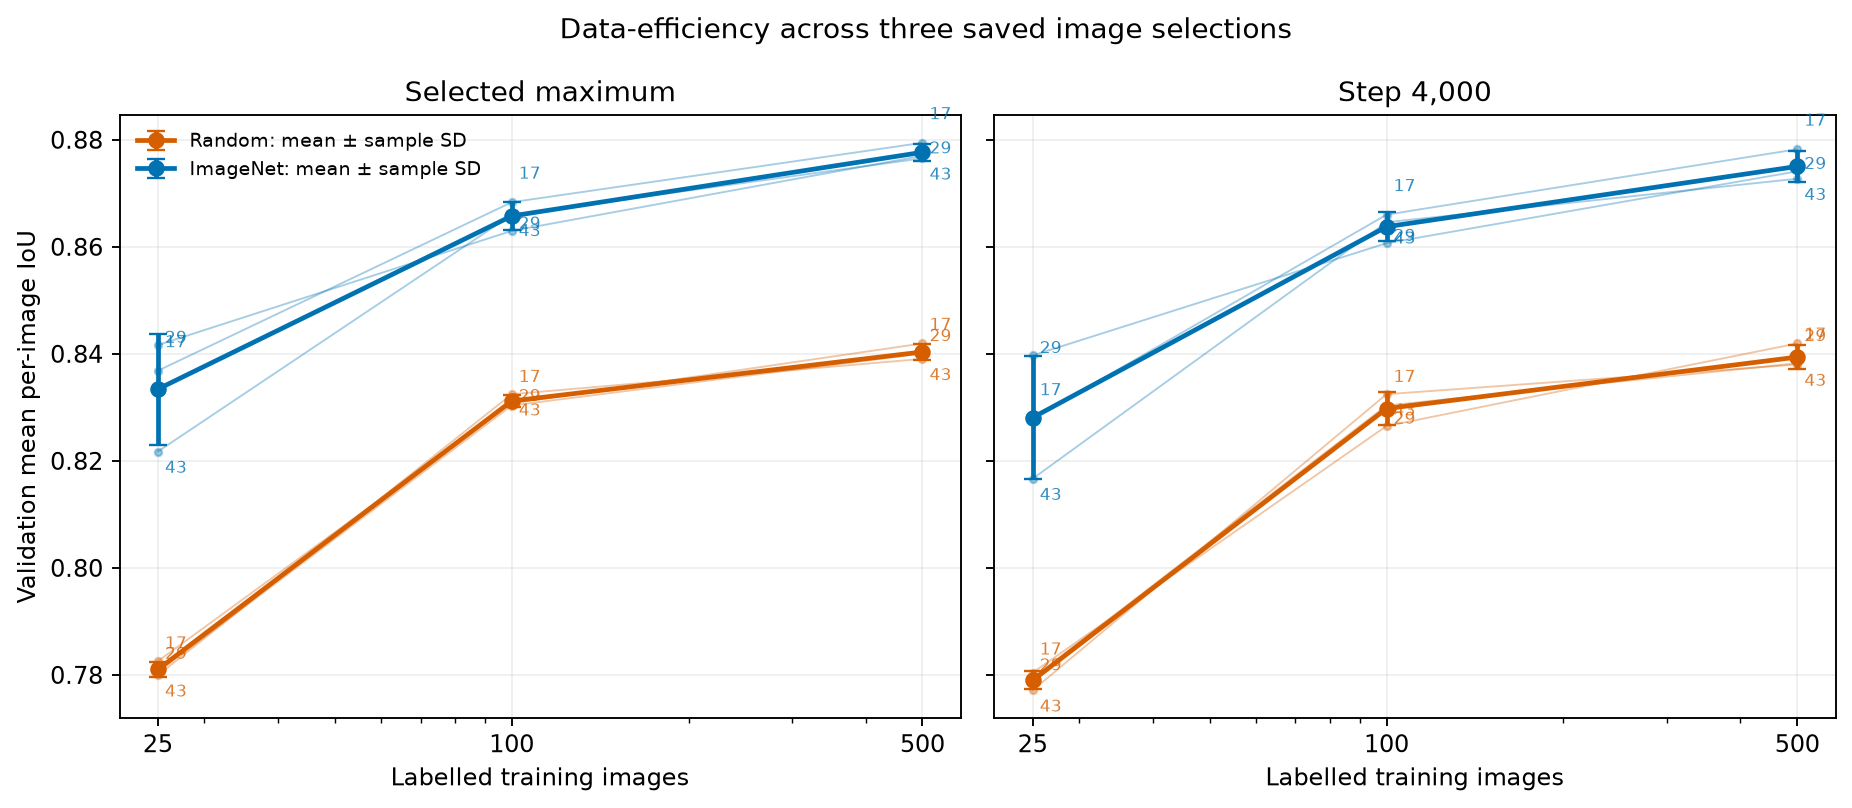

In [4]:
display(Image(filename=ROOT / 'reports/figures/data_efficiency_summary.png'))

In [5]:
display(SUMMARY.rename(columns={
    'training_size': 'images', 'initialization': 'initialization',
    'best_iou_mean': 'best-IoU mean',
    'best_iou_sample_sd': 'best-IoU sample SD',
    'endpoint_iou_mean': 'endpoint-IoU mean',
    'endpoint_iou_sample_sd': 'endpoint-IoU sample SD',
}).style.format({
    'best-IoU mean': '{:.3f}', 'best-IoU sample SD': '{:.3f}',
    'endpoint-IoU mean': '{:.3f}', 'endpoint-IoU sample SD': '{:.3f}',
}))

,images,initialization,best-IoU mean,best-IoU sample SD,endpoint-IoU mean,endpoint-IoU sample SD
0,25,imagenet,0.833,0.010,0.828,0.012
1,25,random,0.781,0.001,0.779,0.002
2,100,imagenet,0.866,0.003,0.864,0.003
3,100,random,0.831,0.001,0.830,0.003
4,500,imagenet,0.878,0.002,0.875,0.003
5,500,random,0.840,0.001,0.839,0.002


All three selections show the same broad ordering. Mean best IoU rises from 0.781 to 0.831 to 0.840 for Random and from 0.833 to 0.866 to 0.878 for ImageNet as the labelled set grows from 25 to 100 to 500 images. Sample SD is at most 0.0015 for Random and 0.0104 for ImageNet except for the much smaller SDs at 100 and 500 images. Seed 43 contributes the lower n=25 ImageNet value (0.822), but it does not reverse the initialization ordering or the benefit of more labels.

## 4. Paired pretraining differences and gains from labels

Pairing removes the training-image selection and scheduled data order from each within-subset initialization comparison. Positive differences favor ImageNet. The size gains compare nested subsets within the same repetition and initialization.

In [6]:
paired_columns = {
    'subset_seed': 'seed', 'training_size': 'images',
    'imagenet_minus_random_best_iou': 'best-IoU difference',
    'imagenet_minus_random_iou_step_4000': 'endpoint-IoU difference',
    'imagenet_minus_random_dice': 'Dice difference',
    'imagenet_minus_random_ap': 'AP difference',
}
display(PAIRED[list(paired_columns)].rename(columns=paired_columns).style.format({
    'best-IoU difference': '{:+.3f}', 'endpoint-IoU difference': '{:+.3f}',
    'Dice difference': '{:+.3f}', 'AP difference': '{:+.3f}',
}))

,seed,images,best-IoU difference,endpoint-IoU difference,Dice difference,AP difference
0,17,25,+0.056,+0.048,+0.038,+0.021
1,17,100,+0.038,+0.036,+0.023,+0.006
2,17,500,+0.039,+0.040,+0.024,+0.013
3,29,25,+0.059,+0.059,+0.039,+0.026
4,29,100,+0.032,+0.034,+0.019,+0.005
5,29,500,+0.035,+0.032,+0.022,+0.012
6,43,25,+0.042,+0.040,+0.028,+0.001
7,43,100,+0.034,+0.032,+0.021,+0.003
8,43,500,+0.037,+0.035,+0.022,+0.011


In [7]:
gain_columns = {
    'subset_seed': 'seed', 'initialization': 'initialization',
    'size_change': 'size change', 'best_iou_gain': 'best-IoU gain',
    'endpoint_iou_gain': 'endpoint-IoU gain',
}
display(GAINS[list(gain_columns)].rename(columns=gain_columns).style.format({
    'best-IoU gain': '{:+.3f}', 'endpoint-IoU gain': '{:+.3f}',
}))

,seed,initialization,size change,best-IoU gain,endpoint-IoU gain
0,17,imagenet,25_to_100,+0.031,+0.038
1,17,imagenet,100_to_500,+0.011,+0.012
2,17,random,25_to_100,+0.050,+0.051
3,17,random,100_to_500,+0.010,+0.008
4,29,imagenet,25_to_100,+0.021,+0.021
5,29,imagenet,100_to_500,+0.014,+0.013
6,29,random,25_to_100,+0.048,+0.046
7,29,random,100_to_500,+0.011,+0.015
8,43,imagenet,25_to_100,+0.044,+0.048
9,43,imagenet,100_to_500,+0.011,+0.008


ImageNet leads in all nine pairs. The best-IoU differences range from +0.0418 to +0.0591 at 25 images, +0.0322 to +0.0380 at 100 and +0.0351 to +0.0394 at 500. Gains from 25 to 100 images are consistently larger than gains from 100 to 500: the latter range from +0.0066 to +0.0112 for Random and +0.0106 to +0.0140 for ImageNet. Three image selections support a stable descriptive pretraining advantage and diminishing validation gains, but do not establish a population effect or significance.

## 5. Training trajectories and late behavior

Each figure shows validation IoU, validation loss and the augmented training objective for one saved selection. The dashed line marks the fixed learning-rate reduction after update 2,000. Separate panels preserve individual trajectories rather than hiding selection sensitivity behind an average curve.

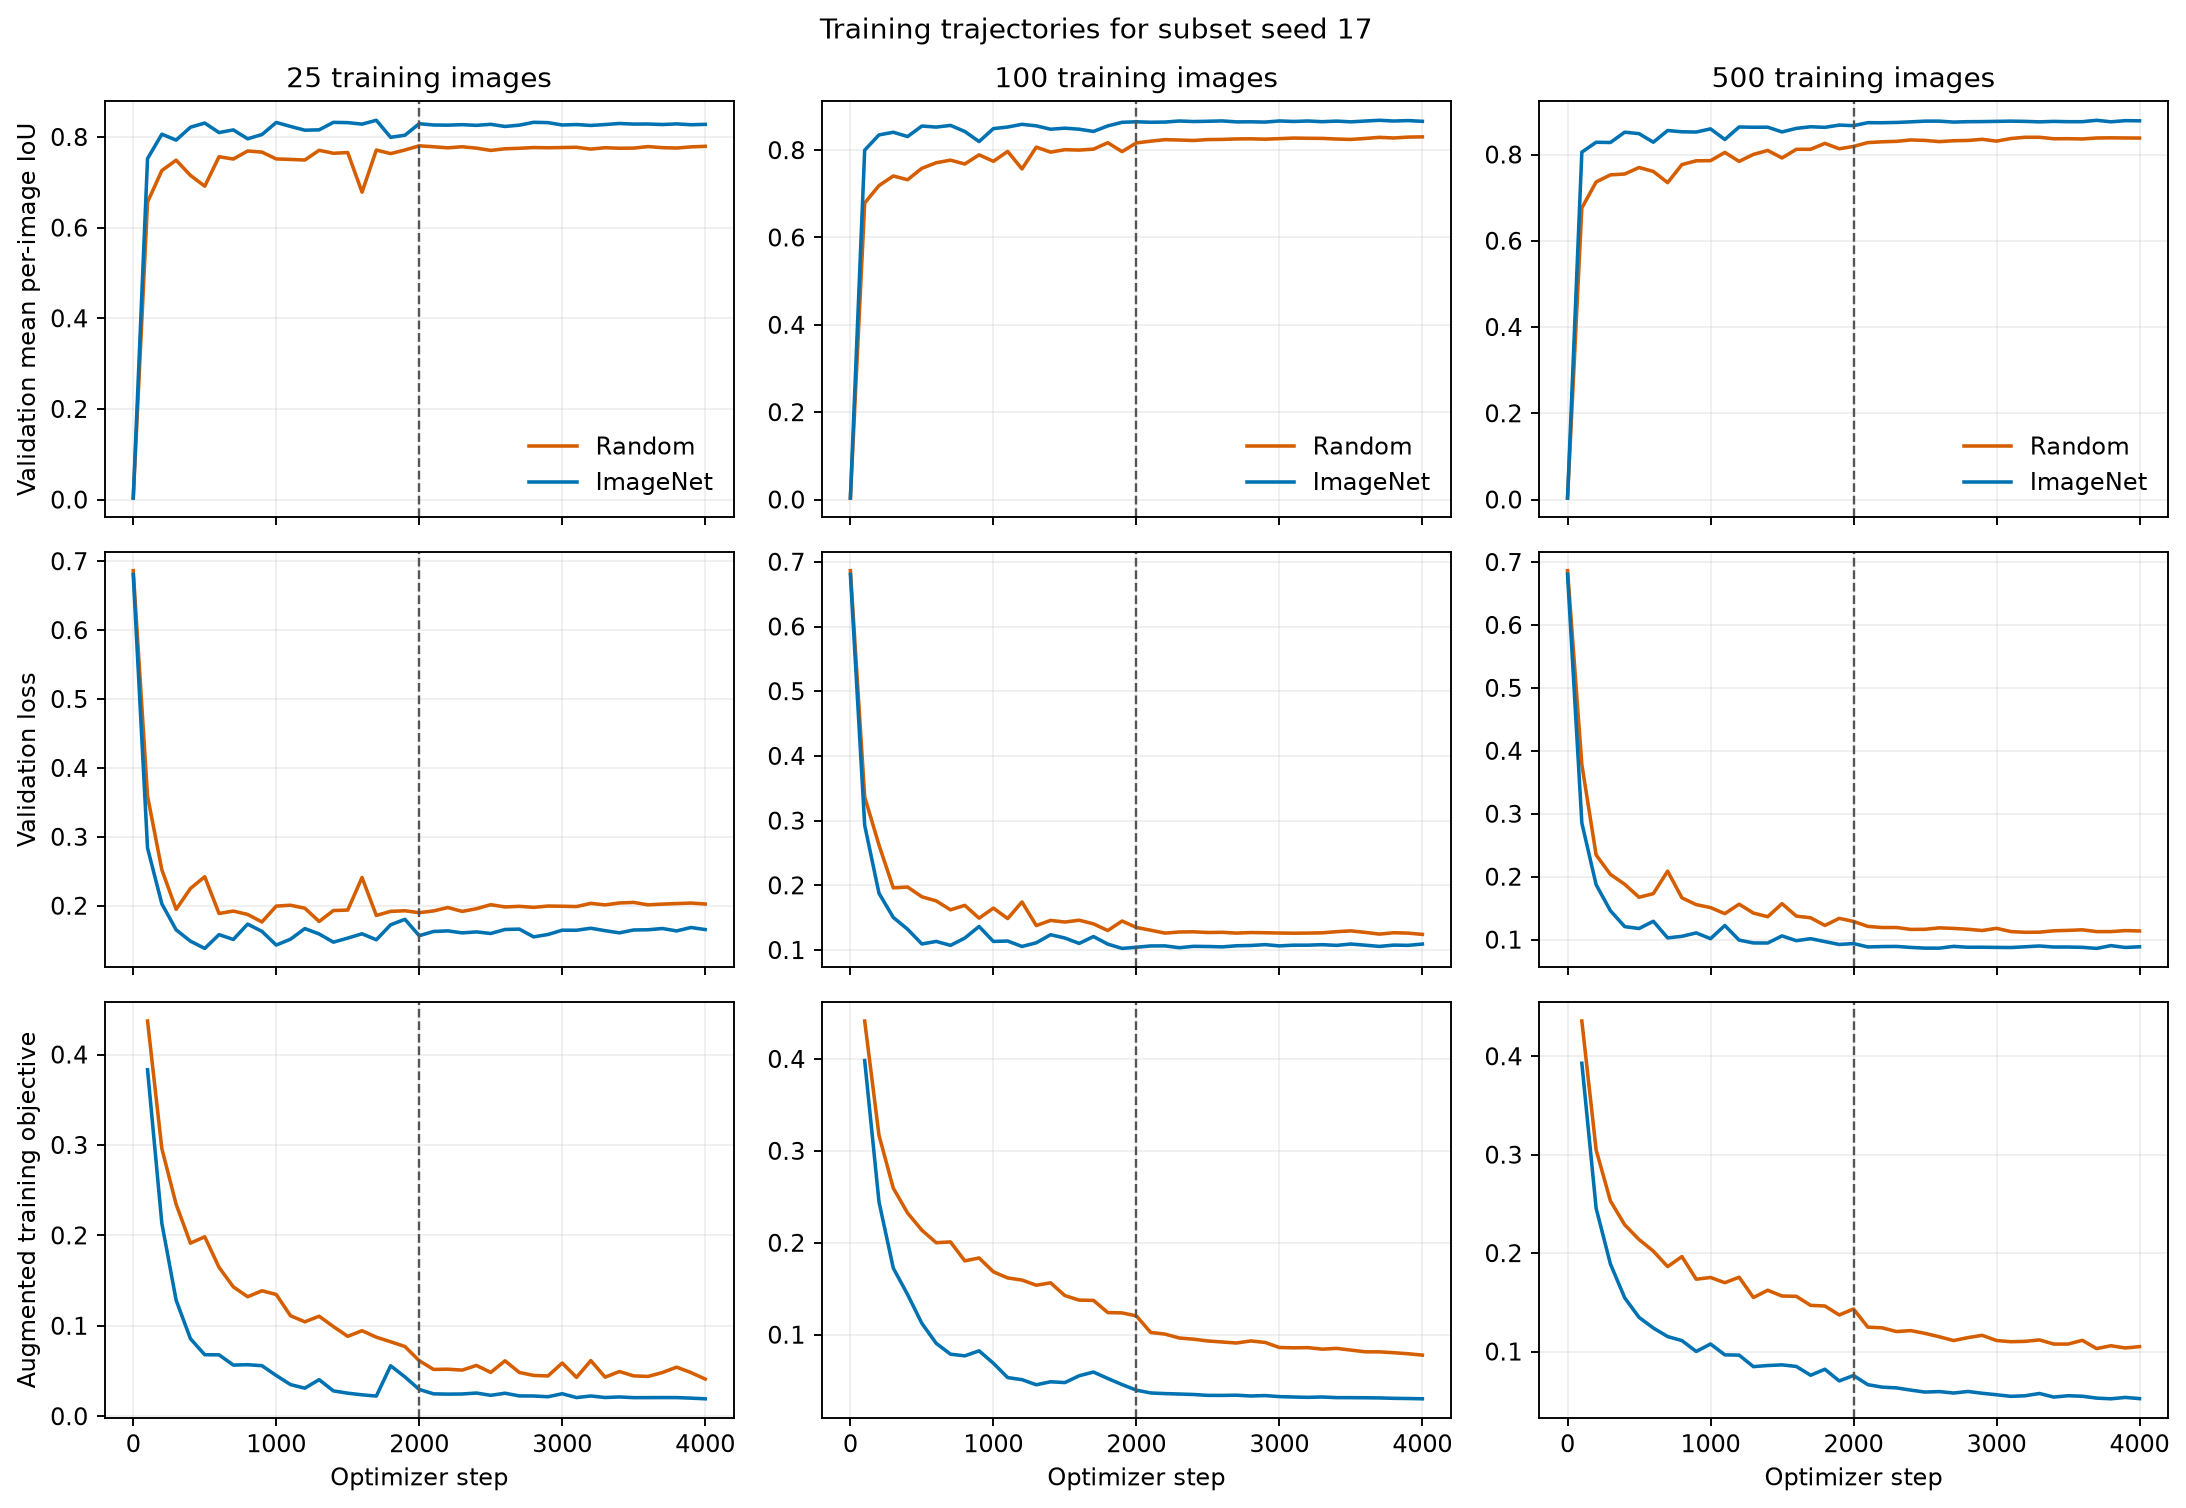

In [8]:
display(Image(filename=ROOT / 'reports/figures/data_efficiency_histories_seed17.png'))

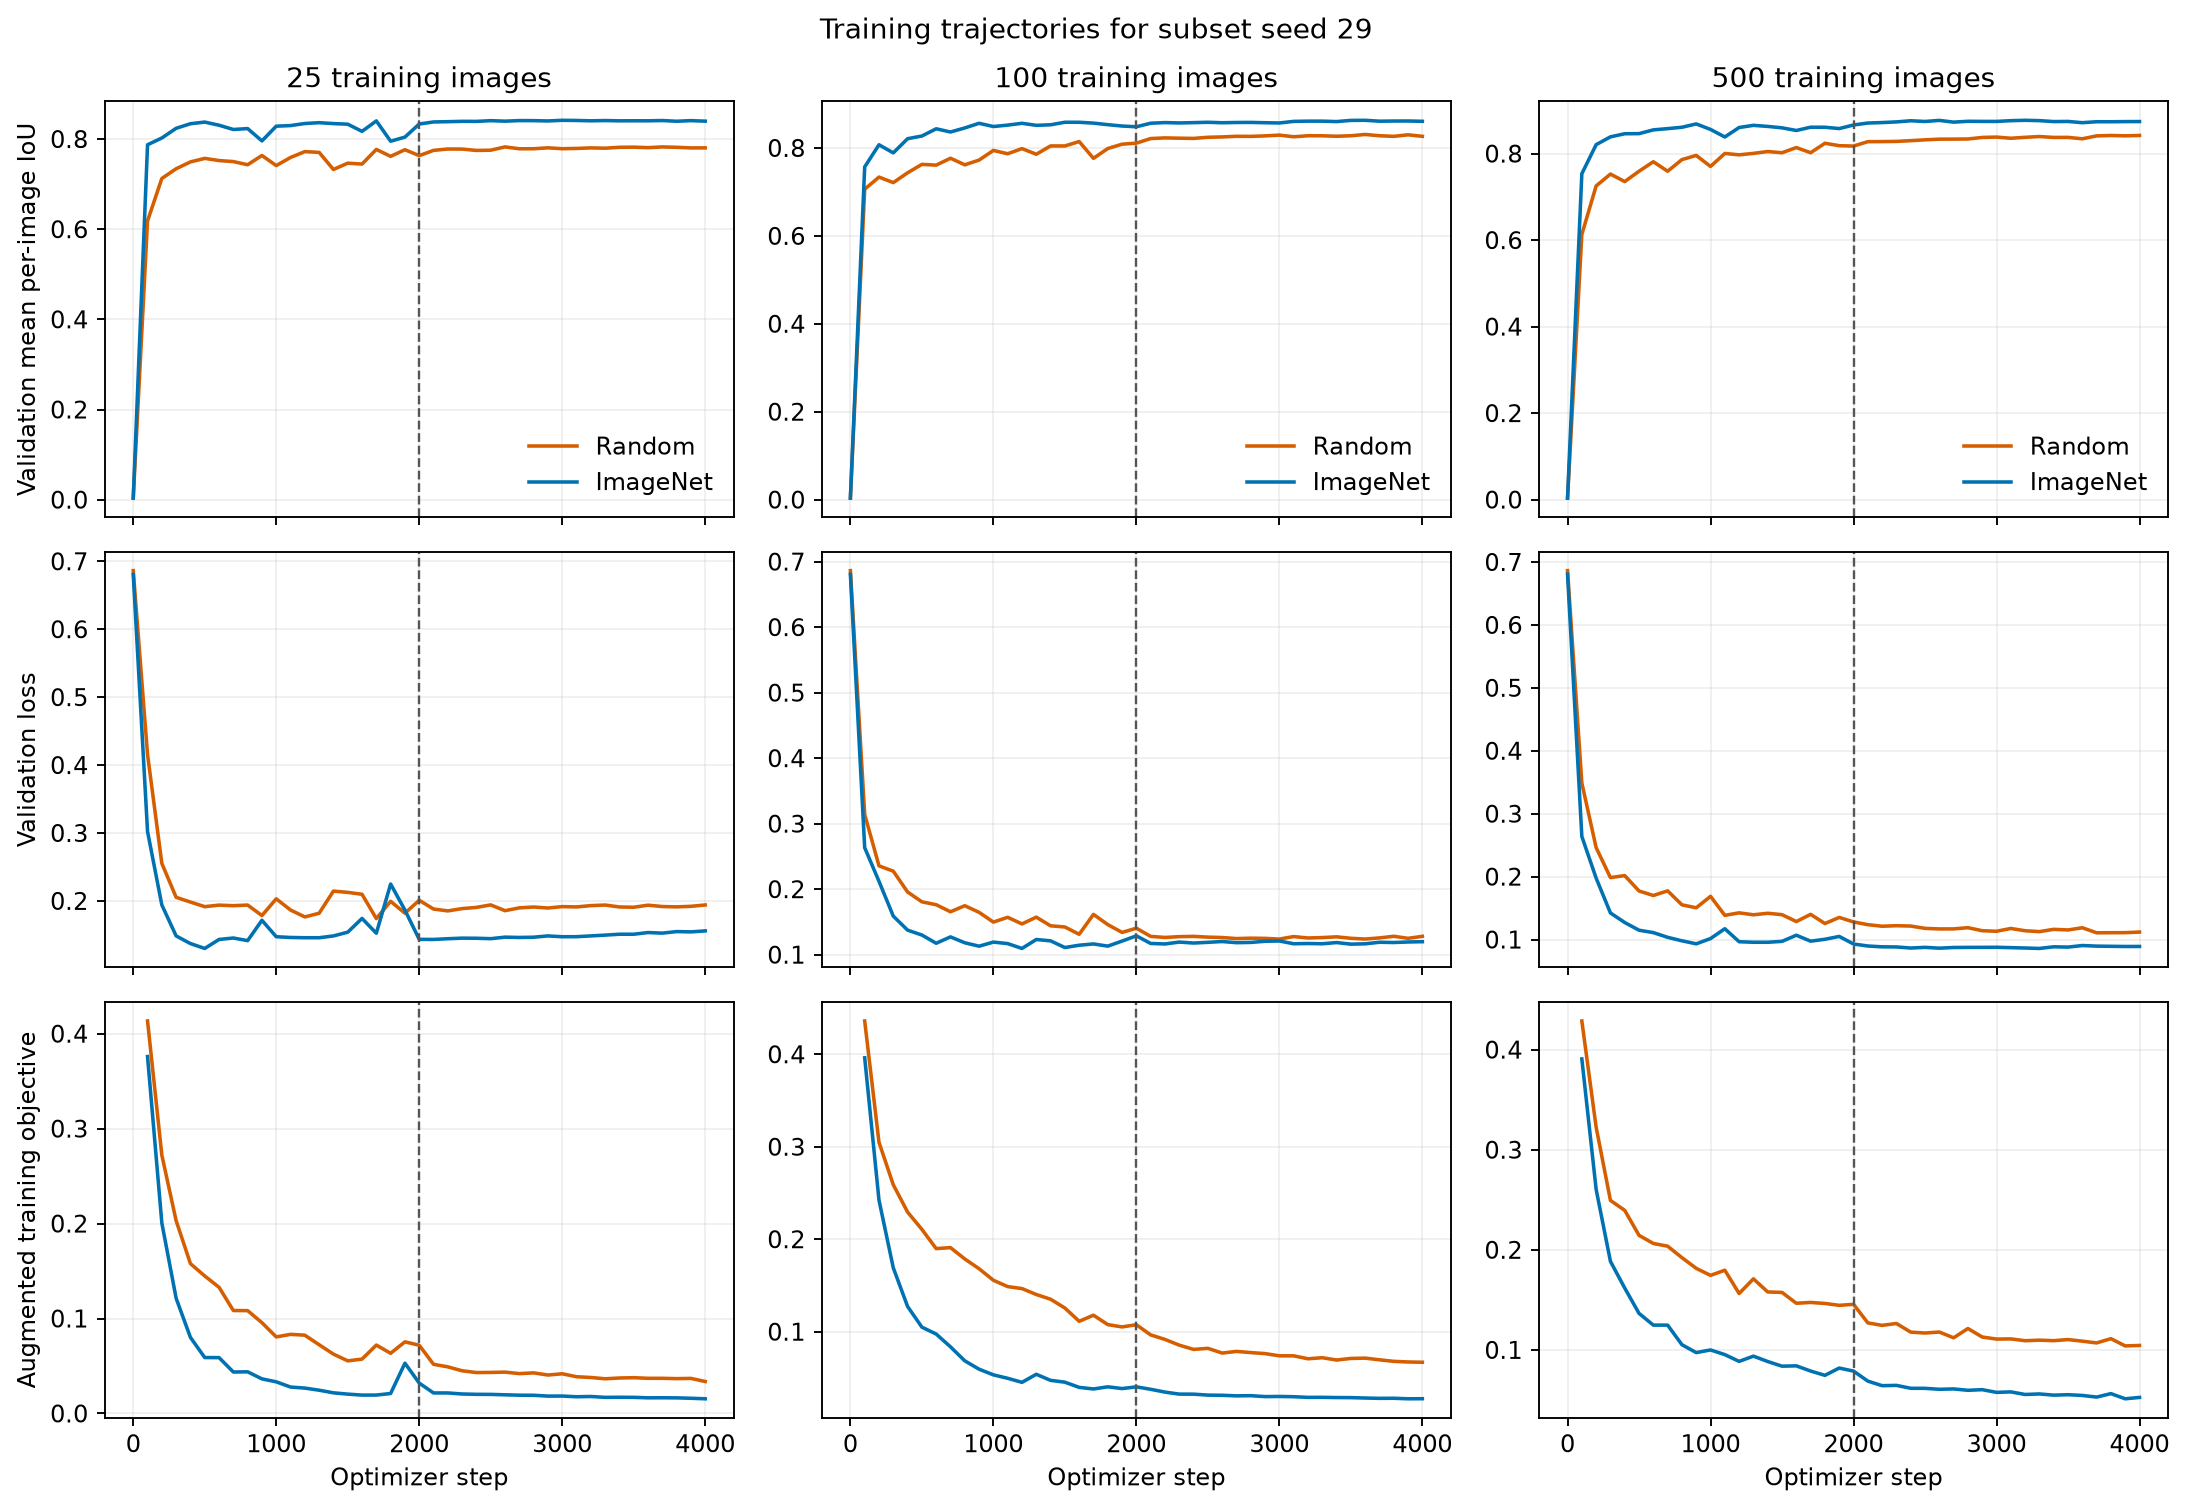

In [9]:
display(Image(filename=ROOT / 'reports/figures/data_efficiency_histories_seed29.png'))

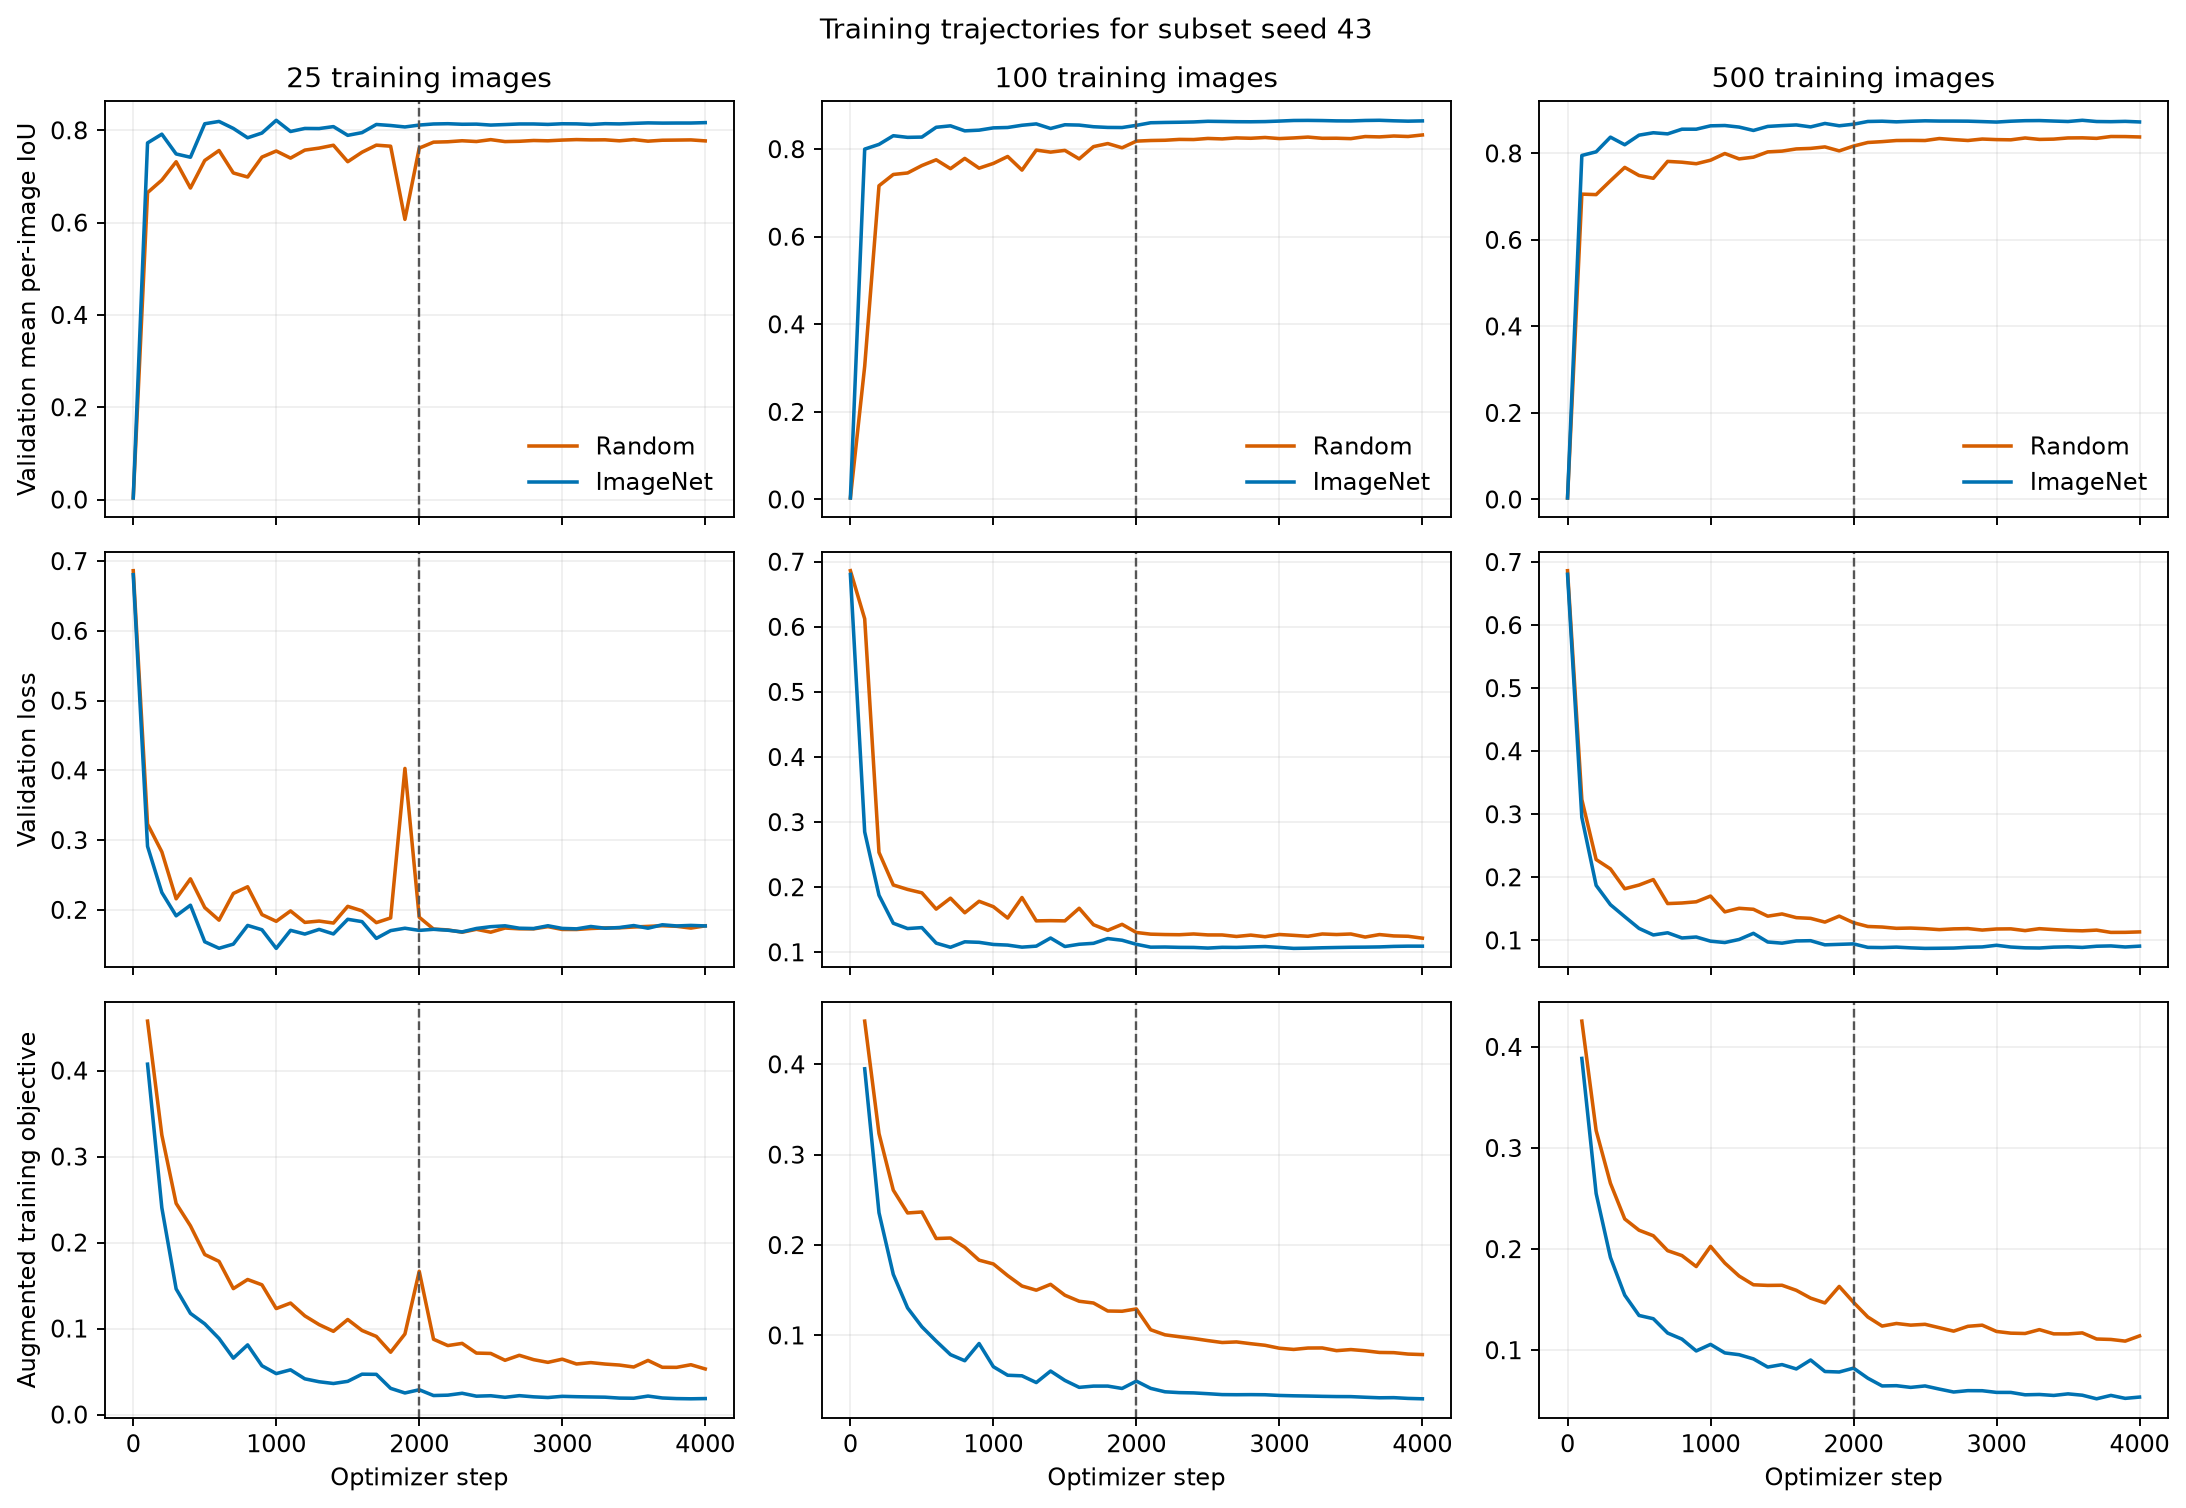

In [10]:
display(Image(filename=ROOT / 'reports/figures/data_efficiency_histories_seed43.png'))

Early overfitting at 25 images repeats in Seed 43: training objectives continue downward while validation loss trends upward late, and selected train–validation IoU gaps remain about 0.13 for both initializations. The exact peak timing is selection-sensitive: Seed 43 ImageNet peaks at update 1,000, whereas its late values are lower.

All three n=500 Random runs continue improving over updates 2,100–4,000, with fitted IoU changes of +0.0054, +0.0073 and +0.0056 per 1,000 updates for seeds 17, 29 and 43. The Seed-43 Random maximum occurs at update 3,800. ImageNet n=500 is flatter and Seed 43 has an approximately zero late slope. The common update budget therefore supports paired comparison but does not demonstrate equal convergence.

## 6. Comparable fit and late diagnostics

Training metrics below are recomputed without augmentation in evaluation mode at the selected checkpoint. Late trends use a linear fit over updates 2,100–4,000; residual SD measures variation around that fitted line.

In [11]:
evaluation_columns = {
    'subset_seed': 'seed', 'training_size': 'images', 'initialization': 'init',
    'selected_training_iou': 'train IoU', 'best_validation_iou': 'val IoU',
    'training_minus_validation_iou': 'IoU gap',
    'selected_training_dice': 'train Dice', 'selected_validation_dice': 'val Dice',
    'selected_training_ap': 'train AP', 'selected_validation_ap': 'val AP',
}
display(RESULTS[list(evaluation_columns)].rename(columns=evaluation_columns).style.format({
    column: '{:.3f}' for column in list(evaluation_columns.values())[3:]
}))

,seed,images,init,train IoU,val IoU,IoU gap,train Dice,val Dice,train AP,val AP
0,17,25,imagenet,0.967,0.837,0.130,0.983,0.906,0.999,0.948
1,17,25,random,0.922,0.781,0.141,0.959,0.868,0.992,0.927
2,17,100,imagenet,0.952,0.868,0.083,0.975,0.926,0.997,0.969
3,17,100,random,0.892,0.830,0.061,0.942,0.903,0.986,0.963
4,17,500,imagenet,0.923,0.879,0.044,0.959,0.933,0.990,0.982
5,17,500,random,0.843,0.840,0.003,0.911,0.909,0.969,0.970
6,29,25,imagenet,0.972,0.842,0.130,0.986,0.908,0.999,0.959
7,29,25,random,0.935,0.783,0.153,0.966,0.869,0.995,0.934
8,29,100,imagenet,0.956,0.863,0.093,0.977,0.922,0.998,0.970
9,29,100,random,0.900,0.831,0.069,0.947,0.903,0.988,0.965


In [12]:
late_columns = {
    'subset_seed': 'seed', 'training_size': 'images', 'initialization': 'init',
    'iou_trend_per_1000': 'IoU trend / 1,000',
    'iou_residual_sd': 'IoU residual SD',
    'loss_trend_per_1000': 'loss trend / 1,000',
    'loss_residual_sd': 'loss residual SD',
}
display(RESULTS[list(late_columns)].rename(columns=late_columns).style.format({
    'IoU trend / 1,000': '{:+.4f}', 'IoU residual SD': '{:.4f}',
    'loss trend / 1,000': '{:+.4f}', 'loss residual SD': '{:.4f}',
}))

,seed,images,init,"IoU trend / 1,000",IoU residual SD,"loss trend / 1,000",loss residual SD
0,17,25,imagenet,+0.0010,0.0020,+0.0025,0.0029
1,17,25,random,+0.0009,0.0020,+0.0051,0.0020
2,17,100,imagenet,+0.0010,0.0010,+0.0015,0.0011
3,17,100,random,+0.0037,0.0012,-0.0011,0.0013
4,17,500,imagenet,+0.0017,0.0011,+0.0001,0.0011
5,17,500,random,+0.0054,0.0020,-0.0036,0.0017
6,29,25,imagenet,+0.0008,0.0008,+0.0063,0.0009
7,29,25,random,+0.0030,0.0016,+0.0027,0.0019
8,29,100,imagenet,+0.0030,0.0011,+0.0002,0.0014
9,29,100,random,+0.0034,0.0016,-0.0004,0.0014


## 7. Limitations and conclusion

This experiment varies the saved training-image selection, not model initialization, order, augmentation or other training randomness. The subsets overlap, especially at 500 images, and all 18 runs reuse one validation region that has informed several project decisions. The three observed values per condition justify reporting individual points and sample SD, not confidence intervals or significance. No result measures transfer to the locked southwest test region.

Within those limits, the findings are consistent: more labelled images improve validation performance with diminishing gains, ImageNet initialization leads in every paired comparison, n=25 shows early overfitting, and n=500 Random is still learning near the common budget limit. The fixed recipe remains the reference for subsequent targeted comparisons; these results do not justify changing its optimization settings.